Let's figure out how to load our data into rustworkx and to see how long it takes to compute pagerank.

In [ ]:
import polars as pl
import rustworkx as rx
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import tqdm

trec_root = Path("~/scratch/trec-tot-2025").expanduser()
dataset_root = trec_root / "data/enwiki/processed"

nodes = pl.read_parquet(dataset_root / "graph/v1/nodes/*.parquet")
display(nodes.count())

edges = pl.read_parquet(dataset_root / "graph/v1/edges/*.parquet")
display(edges.count())

page_id,wikidata_id,node_id
u32,u32,u32
6336917,6336729,6336917


src,dst
u32,u32
118102388,118102388


In [4]:
graph = rx.PyDiGraph()
node_ids = nodes.select("node_id").sort(by="node_id").limit(10).to_series()
display(node_ids.to_list())
index_ids = graph.add_nodes_from(tqdm.tqdm(node_ids))
display(index_ids)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

100%|██████████| 10/10 [00:00<00:00, 97315.64it/s]


NodeIndices[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
graph = rx.PyDiGraph()
_ = graph.add_nodes_from(
    tqdm.tqdm(nodes.select("node_id").sort(by="node_id").to_series())
)
_ = graph.add_edges_from_no_data(
    tqdm.tqdm(zip(edges.select("src").to_series(), edges.select("dst").to_series()))
)

  4%|▍         | 250442/6336917 [00:00<00:02, 2504297.00it/s]

100%|██████████| 6336917/6336917 [00:01<00:00, 3389954.64it/s]
118102388it [01:00, 1937797.51it/s]


In [9]:
graph.num_nodes(), graph.num_edges()

(6336917, 118102388)

In [8]:
rx.is_weakly_connected(graph)

False

In [10]:
len(rx.weakly_connected_components(graph))

72826

In [ ]:
pr = None
%time pr = rx.pagerank(graph, tol=1e-10, max_iter=1000)
len(pr)
x = np.array(list(pr.values()))
display(sorted(x, reverse=True)[:10])
display(sorted(x)[:10])

CPU times: user 39.7 s, sys: 3.23 s, total: 42.9 s
Wall time: 43.1 s


[np.float64(0.02264302334115456),
 np.float64(0.01851809324376961),
 np.float64(0.01461857903280649),
 np.float64(0.005960715061171827),
 np.float64(0.005381628509071759),
 np.float64(0.004326328631108091),
 np.float64(0.004195811976528542),
 np.float64(0.0041893184612145275),
 np.float64(0.004103849414202626),
 np.float64(0.004076286625271359)]

[np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08),
 np.float64(2.422621483457381e-08)]

6336917

np.float64(2.423112264144408e-08)

np.float64(0.02260511098485977)

np.float64(2.423112264144408e-08)

np.float64(2.423112264144408e-08)

np.float64(2.4721673622371778e-08)

np.int64(4602100)

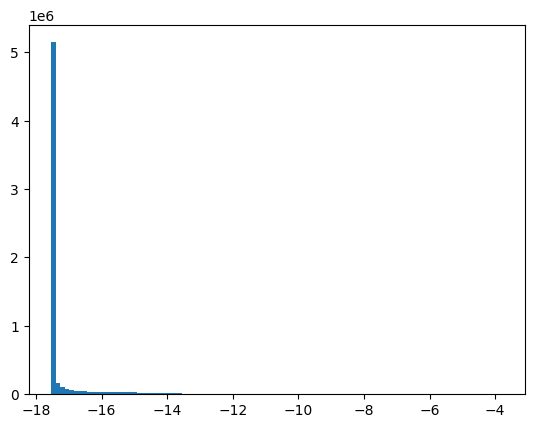

In [50]:
# these values are very small
display(
    len(x),
    min(x),
    max(x),
    np.quantile(x, 0.25),
    np.median(x),
    np.quantile(x, 0.75),
    sum(x == x.min()),
)
plt.hist(np.log(x), bins=100)
plt.show()